## 1 Create Grid

In [1]:
# Code block 0.1

# Import some non-landlab libraries
import numpy as np
import matplotlib as mpl

# Import from the landlab library
from landlab import RasterModelGrid, imshow_grid, imshowhs_grid
from landlab.components import FastscapeEroder, FlowAccumulator, LinearDiffuser, ChannelProfiler
from landlab.plot.graph import plot_graph

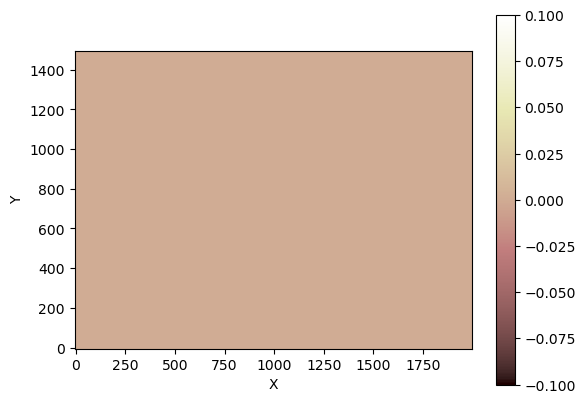

In [2]:
num_rows = 150  # number of grid rows
num_cols = 200  # number of grid columns
dxy = 10  # resolution of raster cell [m], or node horizontal and vertical spacing

# Create the grid
mg = RasterModelGrid((num_rows, num_cols), dxy)

# np.random.seed(0)  
# mg_noise = np.random.rand(mg.number_of_nodes) / 1000.0

zr = mg.add_zeros("topographic__elevation", at="node")
# zr += mg_noise

# Plot the elevation map
imshow_grid(mg, "topographic__elevation")

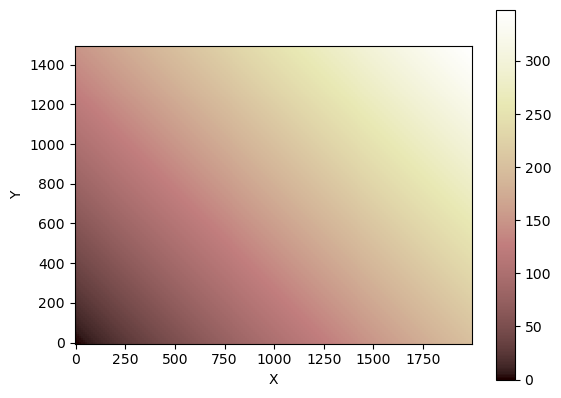

In [3]:
# add a diagonal ramp: low in SW, high in NE
zr += (mg.x_of_node + mg.y_of_node) * 0.1

# Plot the elevation map
imshow_grid(mg, "topographic__elevation")

In [4]:
# Stream power parameters
K_sp = 1.0e-5  # erodibility, units depend on m and n exponents
m_sp = 0.5  # exponent on drainage area
n_sp = 1.0  # exponent on slope

mg.set_closed_boundaries_at_grid_edges(True, True, True, False)

# Create the flow accumulation and fluvial incision components
fr = FlowAccumulator(mg, flow_director="D8")
fs = FastscapeEroder(mg, m_sp=m_sp, n_sp=n_sp, K_sp=K_sp)

In [5]:
dt = 1000  # time step [yr]
modeled_time = 0  # amount of time the landscape has evolved [yr]
time_to_run = 1e6  # time for the model loop to run [yr]

nsteps = int(time_to_run / dt)  # number of model time steps

uplift_rate = 0.001  # uplift rate [m/yr]
uplift_length = uplift_rate * dt # length of uplift per time step [m]

In [6]:
for i in range(nsteps):
    zr[mg.core_nodes] += uplift_length  # uplift the landscape
    fr.run_one_step()  # route flow
    fs.run_one_step(dt)  # fluvial incision
    modeled_time += dt  # update time keeper
    
    # sometimes it's nice to see that the model is progressing, especially if it's slow
    if int(modeled_time % 1e5) == 0:
        print("model run time",modeled_time)
        print("maximum elevation",max(mg.at_node["topographic__elevation"][mg.core_nodes]))
        

model run time 100000
maximum elevation 444.3726325631841
model run time 200000
maximum elevation 542.3097813065211
model run time 300000
maximum elevation 639.554497995184
model run time 400000
maximum elevation 735.0611880889034
model run time 500000
maximum elevation 827.823951451488
model run time 600000
maximum elevation 919.0518261797331
model run time 700000
maximum elevation 1009.3846540992121
model run time 800000
maximum elevation 1100.327788199961
model run time 900000
maximum elevation 1188.6848517697197
model run time 1000000
maximum elevation 1273.0234885879383


##### Visualize the topography

##### Print all the Fields in the Grid

In [7]:
mg.at_node.keys()

['topographic__elevation',
 'water__unit_flux_in',
 'drainage_area',
 'flow__data_structure_delta',
 'flow__upstream_node_order',
 'surface_water__discharge',
 'flow__sink_flag',
 'flow__link_to_receiver_node',
 'flow__receiver_node',
 'topographic__steepest_slope']

In [8]:
mg.at_node["topographic__elevation"]

array([  0.,   1.,   2., ..., 346., 347., 348.], shape=(30000,))

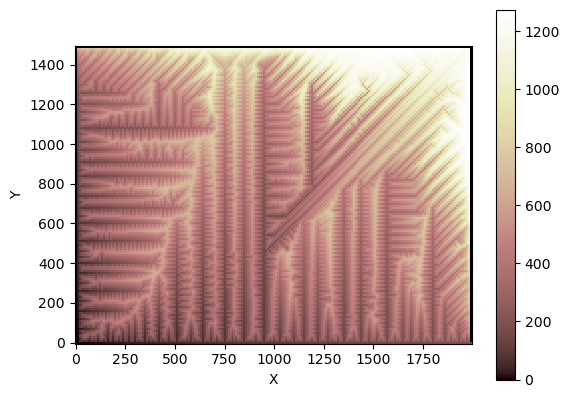

In [9]:
imshow_grid(mg, "topographic__elevation")

Text(0.5, 1.0, 'log10 of drainage area, time = 1000000')

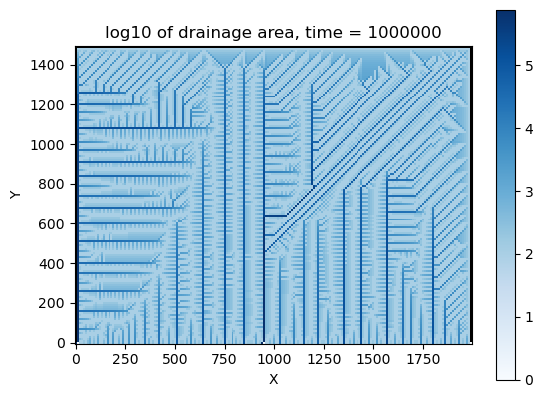

In [10]:
# calculate the log of drainage area array
log10area = np.log10(mg.at_node["drainage_area"] + 1.0)

# make the map
imshow_grid(mg, log10area, cmap="Blues")
title_text = f"log10 of drainage area, time = {modeled_time}"
mpl.pyplot.title(title_text)

## 2 Create Channels

## 3 Erosion Deposition Component

## 4 Precipitation Scenarios